In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint

import hydra
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.3, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
alt_ids = {
    # ('jfu3yhqq', 'SM (EM,VE,Tr)'): {},
    ('ny8j7nt4', r'FM-TF ($x_1-x_0$, $\lambda = 1$)'): {},
    ('3mer31qu', r'FM-TF ($u_t(x|x_1)$, $\lambda=1$)'): {},
    ('0wrmfaku', r'FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$)'): {},
    # ('5xlltk8g', r'FM-TF ($u_t(x|x_1)$, $\lambda=1.5$)'): {},
    # ('5d2rymkn', r'FM-TF ($u_t(x|x1)$, $\lambda=2$)'): {},
}
label_to_alt_id = dict(map(reversed, alt_ids))
assert len(alt_ids) == len(label_to_alt_id), "Do two alt_id's have the same plot label?"

In [4]:
engine = conf.get_engine()
with conf.sa.orm.Session(engine) as db:
    cfgs = db.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_([k[0] for k in alt_ids])))
    cfgs = {c.alt_id: c for (c,) in cfgs}
    cfgs = {k: {'cfg': cfgs[k[0]]} for k in alt_ids}
    pprint.pp(cfgs)

{('ny8j7nt4', 'FM-TF ($x_1-x_0$, $\\lambda = 1$)'): {'cfg': Conf(root_dir='/home/sci/ttransue/GitHub/Data-Assimilation-Flow-Matching',
                                                                 out_dir='/home/sci/ttransue/out/dafm',
                                                                 run_subdir='runs',
                                                                 prediction_filename='trajectories.parquet',
                                                                 device='cuda',
                                                                 alt_id='ny8j7nt4',
                                                                 rng_seed=2376999025,
                                                                 fit=True,
                                                                 id=3,
                                                                 dataset=DoubleWell(predicted_state_count=1000,
                                                            

In [5]:
for v in cfgs.values():
    v['trajectories'] = pd.read_parquet(v['cfg'].run_dir/v['cfg'].prediction_filename)

In [6]:
dim = 0
for v in cfgs.values():
    v['trajectories'][f'predicted_state_mean_{dim}'] = v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.contains(f'predicted_state_[0-9]+_dim_{dim}')]].mean(axis=1)

In [7]:
v['trajectories']

,times,true_state_dim_0,observation_dim_0,predicted_state_0_dim_0,predicted_state_1_dim_0,predicted_state_2_dim_0,predicted_state_3_dim_0,predicted_state_4_dim_0,predicted_state_5_dim_0,predicted_state_6_dim_0,...,predicted_state_991_dim_0,predicted_state_992_dim_0,predicted_state_993_dim_0,predicted_state_994_dim_0,predicted_state_995_dim_0,predicted_state_996_dim_0,predicted_state_997_dim_0,predicted_state_998_dim_0,predicted_state_999_dim_0,predicted_state_mean_0
0,0.000000,-1.008885,-1.037598,-0.958448,-1.061862,-1.049598,-0.800314,-0.866101,-1.035766,-0.689744,...,-1.389839,-0.865106,-1.102382,-1.238401,-0.958976,-1.227490,-1.172050,-1.407979,-0.986752,-1.003169
1,0.100000,-0.990047,-0.911333,-0.979227,-1.222478,-1.075954,-0.907873,-0.982135,-1.209954,-1.103851,...,-0.807294,-0.637178,-0.738139,-0.895697,-1.158148,-0.689808,-0.874421,-0.745202,-1.361211,-0.909808
2,0.200000,-0.963767,-0.811504,-0.906433,-0.656553,-0.230900,-0.723375,-0.787289,-1.030025,-0.515876,...,-1.317814,-0.826482,-0.186115,-0.928515,-0.772833,-0.558070,-0.736181,-1.056418,-0.743718,-0.807997
3,0.300000,-1.020289,-0.946174,-1.658690,-0.997834,-0.708696,-1.015579,-0.732892,-0.852669,-1.086930,...,-0.711899,-1.749449,-0.566611,-0.879247,-0.704361,-0.846254,-1.380259,-0.958083,-0.947792,-0.926074
4,0.400000,-1.034468,-0.936765,-0.772236,-1.376239,-0.682568,-0.944972,-1.651976,-1.005683,-1.329631,...,-1.374967,-0.933619,-1.450465,-0.573126,-0.671163,-0.527327,-0.865264,-0.769105,-0.882435,-0.939470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,9.600000,-0.861362,-0.609281,-0.755437,-0.198643,-0.187156,-1.306837,-0.989084,-0.609670,0.310904,...,-0.193436,-0.557206,-0.504233,-0.896496,-1.043068,-0.044547,-0.985795,-1.238991,-0.679317,-0.639454
97,9.700000,-0.984532,-0.911681,-1.230931,-0.629599,-1.329245,-1.519692,-0.949918,-1.064252,-1.168779,...,-0.485325,-1.056409,-1.257739,-1.195252,-0.889090,-0.998843,-0.078779,-1.113681,-0.603061,-0.894405
98,9.800000,-0.970493,-1.089546,-1.436889,-1.055747,0.291280,-0.924943,-1.070771,-0.896759,-1.277470,...,-0.755928,-1.203031,-0.950454,-1.198197,-1.545409,-0.959557,-0.822504,-2.071532,-1.173756,-1.057448
99,9.900001,-0.920799,-0.907130,-1.719727,-1.172047,-1.088900,-1.023020,-0.552032,-1.131028,-0.598862,...,-0.891736,-1.146064,-0.729232,-0.746994,-0.489321,-1.011561,-0.698045,-0.952925,-0.987887,-0.910524


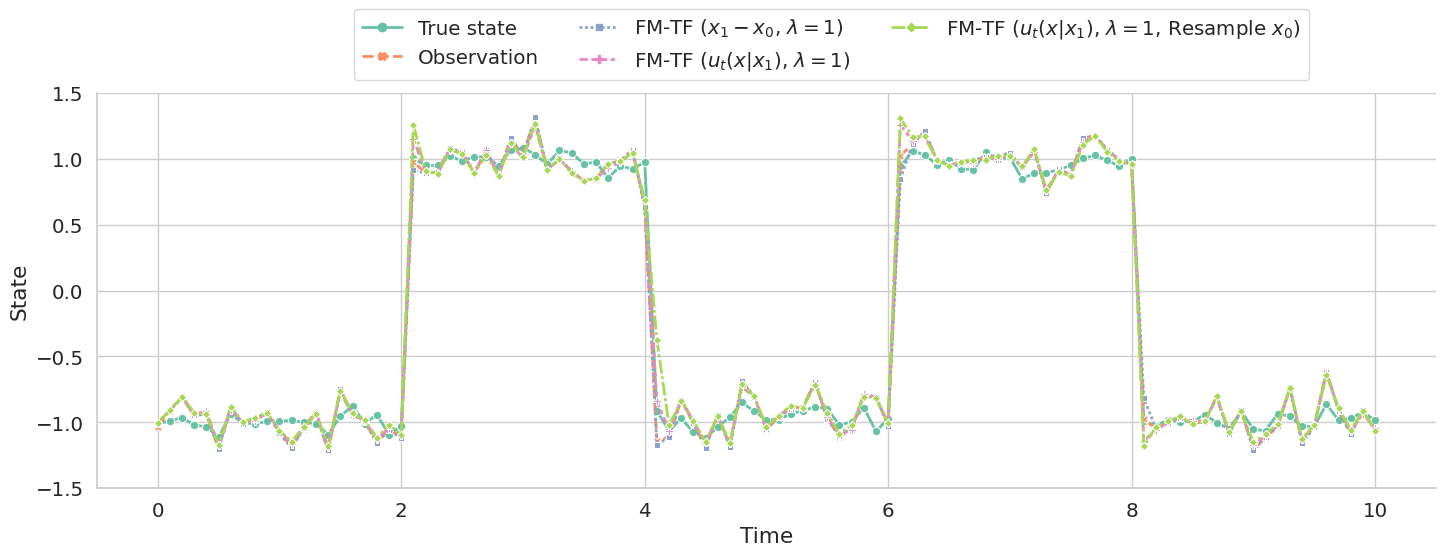

In [8]:
df_line = pd.concat([
    v['trajectories']['times'].rename('Time'),
    v['trajectories'][f'true_state_dim_{dim}'].rename('True state'),
    v['trajectories'][f'observation_dim_{dim}'].rename('Observation'),
    *(
        v['trajectories'][f'predicted_state_mean_{dim}'].rename(f'{k[1]}')
        for k, v in cfgs.items()
    )
], axis=1)
df_line_melt = df_line.melt(id_vars=['Time'], var_name='Source', value_name='State')
plot = (
    sns.relplot(
        data=df_line_melt,
        kind='line',
        x='Time',
        y='State',
        hue='Source',
        style='Source',
        markers=True,
        aspect=3,
        linewidth=2,
        # hue_order=['true_state', 'predicted_state_mean'],
    )
    .set(ylim=(-1.5, 1.5))
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(df_line_melt['Source'].unique()), 3),
    title='',
    bbox_to_anchor=(.455, 1.14),
    frameon=True,
    fancybox=True,
)

In [9]:
df = df_line
print('RMSE')
print()
print(df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).pow(2).mean().pow(1/2))
print()
print('MAE')
df.transform(lambda x: x if x.name == 'Time' else x - df['True state']).abs().mean()
# (df.T - df['True state']).T.pow(2).sum()

RMSE

Time                                                 5.787919
True state                                           0.000000
Observation                                          0.112803
FM-TF ($x_1-x_0$, $\lambda = 1$)                     0.116943
FM-TF ($u_t(x|x_1)$, $\lambda=1$)                    0.107396
FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$)    0.123462
dtype: float32

MAE


Time                                                 5.000000
True state                                           0.000000
Observation                                          0.090422
FM-TF ($x_1-x_0$, $\lambda = 1$)                     0.094238
FM-TF ($u_t(x|x_1)$, $\lambda=1$)                    0.085835
FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$)    0.092480
dtype: float32

In [10]:
plots.save_all_subfigures(plot, 'Predictions', renaming=label_to_alt_id)

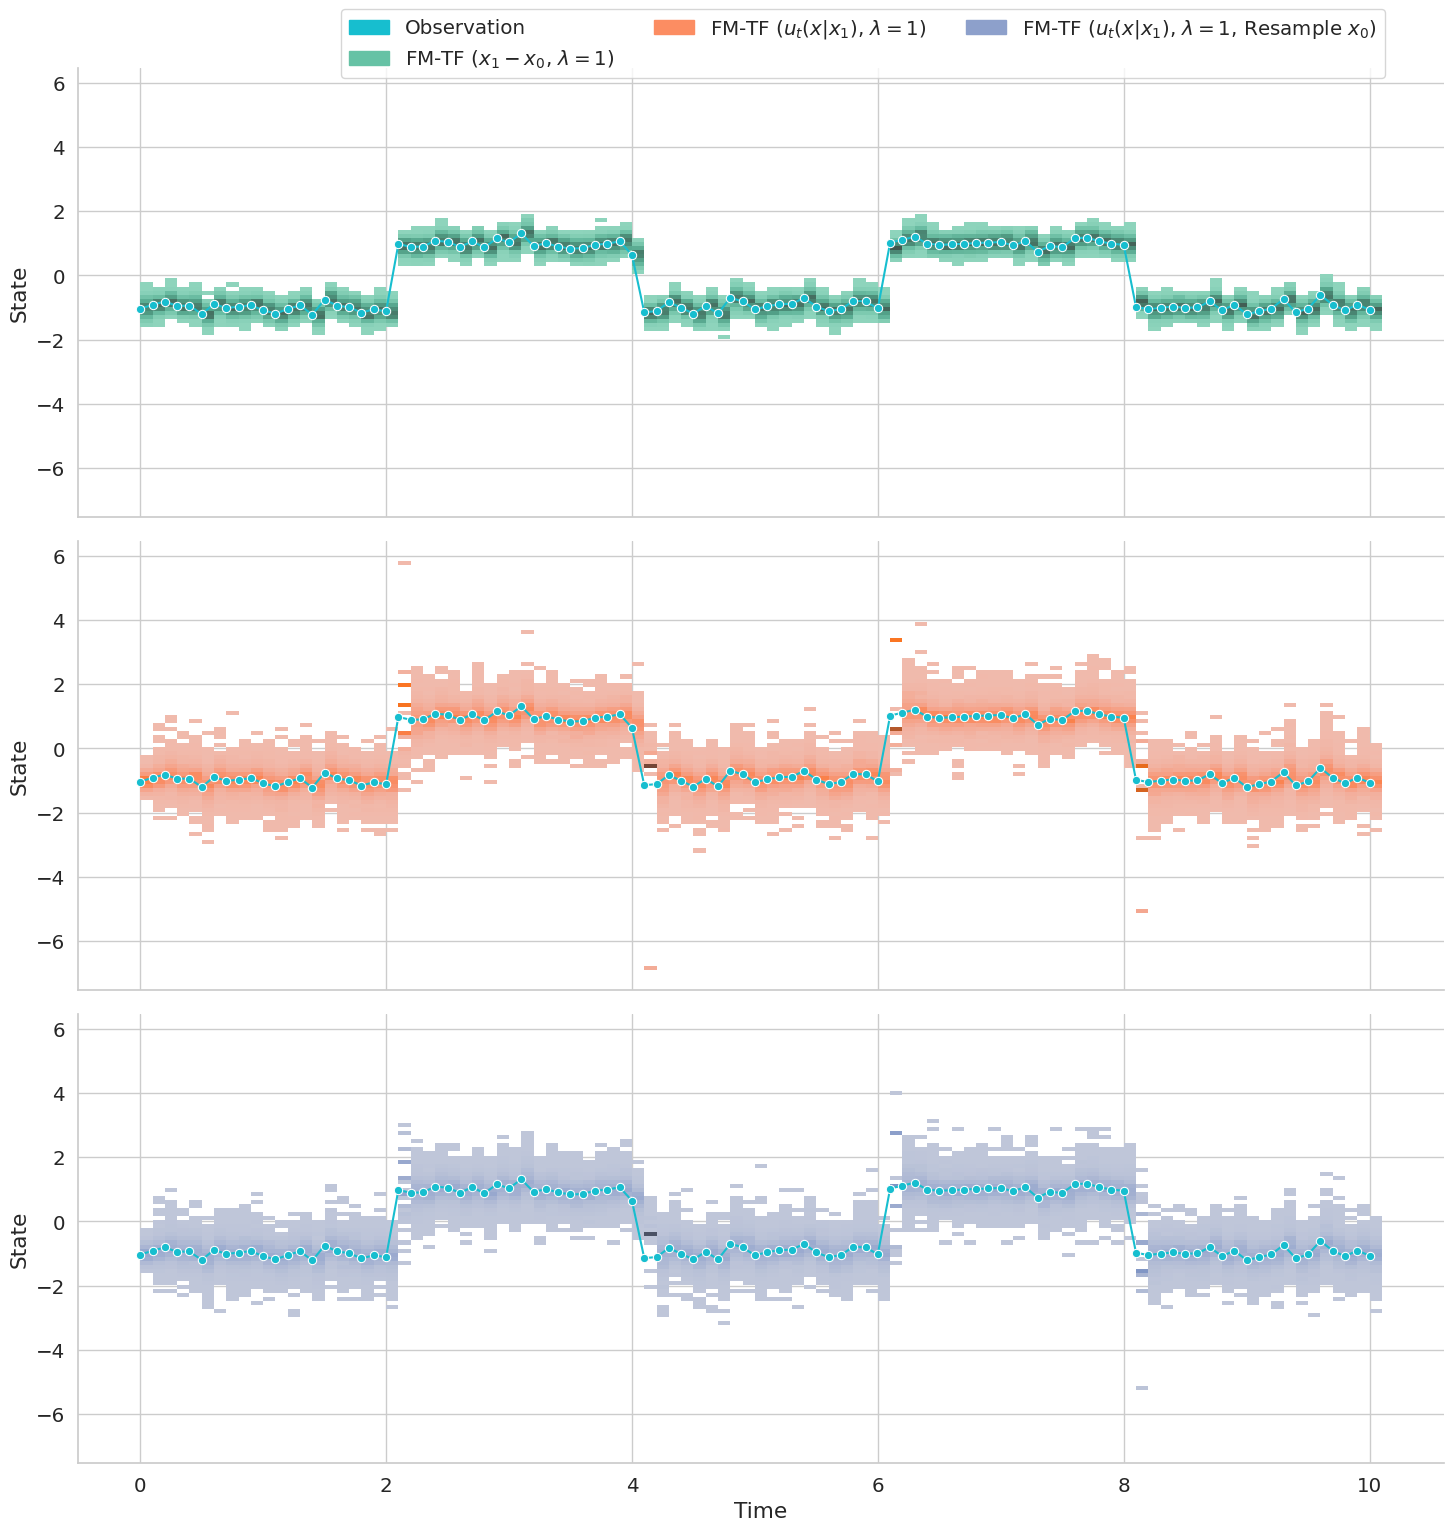

In [11]:
dim = 0
df_hist = (
    pd.concat([
        v['trajectories'] for v in cfgs.values()
    ], keys=[k[1] for k in cfgs], names=['Model'])
    .reset_index()
    .melt(id_vars=['Model', 'times'], var_name='Source', value_name='State', value_vars=v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')])
    .rename(columns={'times': 'Time'})
)
#.melt(id_vars=['Time'], var_name='Source', value_name='State')
df_hist
plot = (
    sns.displot(
        data=df_hist,
        x='Time',
        y='State',
        row='Model',
        hue='Model',
        hue_order=['Observation', *df_hist['Model'].unique()],# 'True state'],
        palette=['tab:cyan', *sns.color_palette()[:len(df_hist['Model'].unique())]],# 'tab:red'],
        bins=(v['trajectories']['times'], 101),
        binwidth=(v['trajectories']['times'].diff().iloc[-1], None),
        aspect=3,
        common_norm=False,
        # binrange=(None, (-3, 3)),
    )
    .set_titles('')
    # .set(xticks=[])
)
plot.map(
    sns.lineplot,
    data=df_line_melt.loc[(df_line_melt['Source'] == 'Observation'), ['Time', 'State', 'Source']],
    x='Time',
    y='State',
    color='tab:cyan',
    style='Source',
    markers=True,
)
# plot.map(
#     sns.lineplot,
#     data=df_line_melt.loc[(df_line_melt['Source'] == 'True state'), ['Time', 'State', 'Source']],
#     x='Time',
#     y='State',
#     color='tab:red',
#     style='Source',
#     markers=True,
# )
sns.move_legend(
    plot,
    loc='upper center',
    ncol=min(len(df_hist['Source'].unique()), 3),
    title='',
    bbox_to_anchor=(.455, 1.03),
    frameon=True,
    fancybox=True,
)

In [12]:
plots.save_all_subfigures(plot, 'PredictedStateHistogram', renaming=label_to_alt_id)

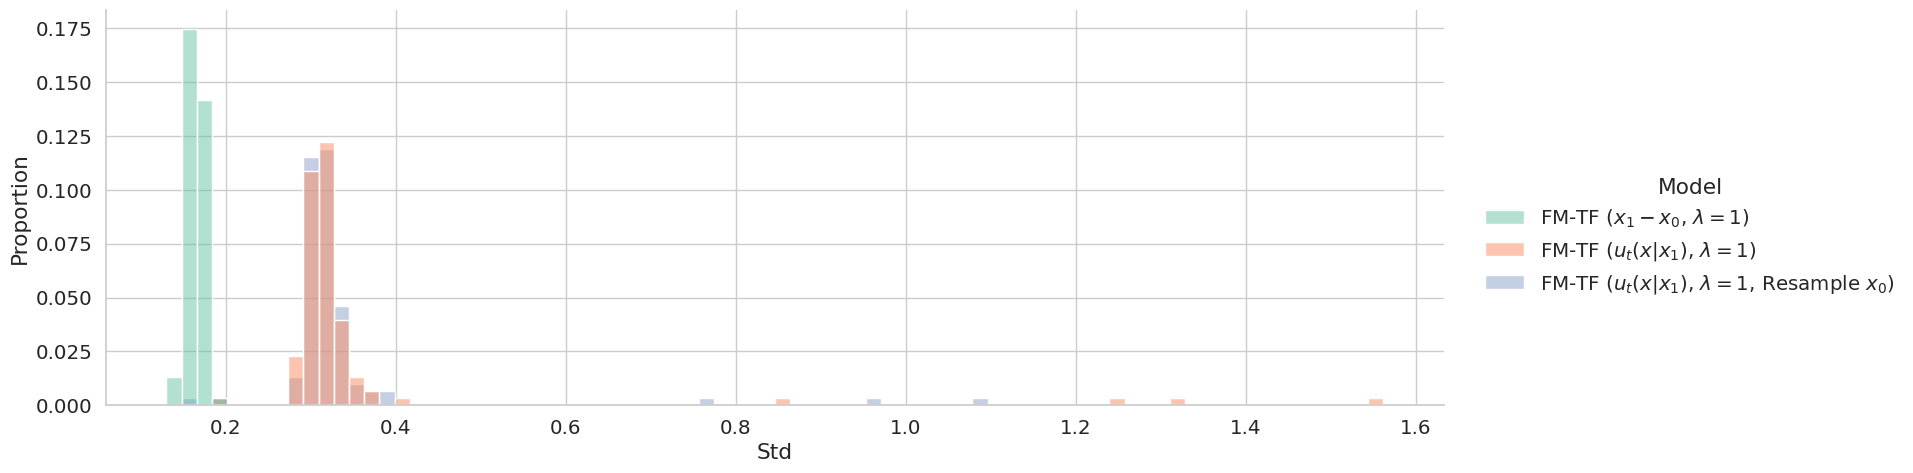

In [13]:
std = pd.concat([
    v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')]]
    .std(axis=1)
    .rename('Std')
    for k, v in cfgs.items()
], keys=[k[1] for k in cfgs], names=['Model']).reset_index()
plot = (
    sns.displot(
        data=std,
        x='Std',
        hue='Model',
        stat='proportion',
        aspect=3,
        bins=80,
    )
)
# plot.axes[0][0].set_xticks(np.arange(0, std['Std'].max() + .1, .1))
plot

In [14]:
std

,Model,level_1,Std
0,"FM-TF ($x_1-x_0$, $\lambda = 1$)",0,0.198596
1,"FM-TF ($x_1-x_0$, $\lambda = 1$)",1,0.160097
2,"FM-TF ($x_1-x_0$, $\lambda = 1$)",2,0.163306
3,"FM-TF ($x_1-x_0$, $\lambda = 1$)",3,0.160647
4,"FM-TF ($x_1-x_0$, $\lambda = 1$)",4,0.175553
...,...,...,...
298,"FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$)",96,0.361292
299,"FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$)",97,0.331699
300,"FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$)",98,0.301700
301,"FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$)",99,0.300792


In [15]:
stats = pd.concat([
    v['trajectories'][v['trajectories'].columns[v['trajectories'].columns.str.startswith('predicted_state')]]
    .std(axis=1, ddof=0)
    .describe()
    .rename(k[1])
    .to_frame().T
    for k, v in cfgs.items()
])
print(stats[stats.columns[stats.columns != 'count']].to_latex())

\begin{tabular}{lrrrrrrr}
\toprule
 & mean & std & min & 25% & 50% & 75% & max \\
\midrule
FM-TF ($x_1-x_0$, $\lambda = 1$) & 0.164351 & 0.008485 & 0.130025 & 0.160567 & 0.164650 & 0.169567 & 0.198497 \\
FM-TF ($u_t(x|x_1)$, $\lambda=1$) & 0.350927 & 0.191265 & 0.198497 & 0.302203 & 0.311688 & 0.324918 & 1.560940 \\
FM-TF ($u_t(x|x_1)$, $\lambda=1$, Resample $x_0$) & 0.332031 & 0.113434 & 0.148026 & 0.301613 & 0.312565 & 0.325207 & 1.095538 \\
\bottomrule
\end{tabular}

